In [22]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

print(df.info())
print(df.describe(include='all'))
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
          survived      pclass   sex         age       sibsp       parch  \
count   891.0

In [23]:
# Missing Percentage
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing":missing,
    "Percentage":missing_percent
})

missing_df = missing_df[missing_df["Missing"]>0]

print(missing_df)

             Missing  Percentage
age              177   19.865320
embarked           2    0.224467
deck             688   77.216611
embark_town        2    0.224467


In [24]:
# Task 2 Missing Value Handling

df = df.dropna(subset=["embarked","embark_town"])

df["age"] = df["age"].fillna(df["age"].median())

df = df.drop(columns=["deck"])

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    str     
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        889 non-null    category
 9   who          889 non-null    str     
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        889 non-null    str     
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 86.1 KB


In [26]:
# Save offline copy
df.to_csv("titanic.csv",index=False)

<Axes: xlabel='age', ylabel='Count'>

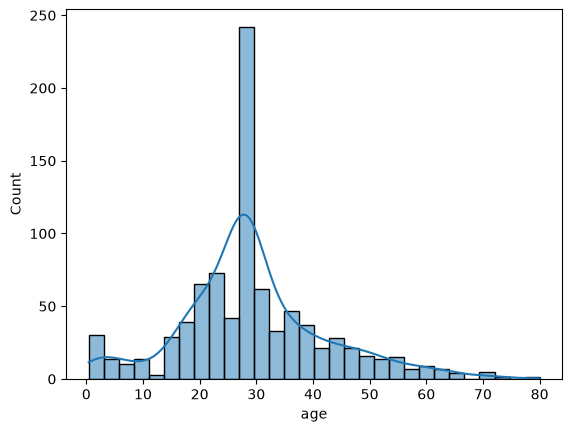

In [27]:
#  Task 3 Univariate Analysis

# Histogram

sns.histplot(df["age"],kde=True)

<Axes: xlabel='age'>

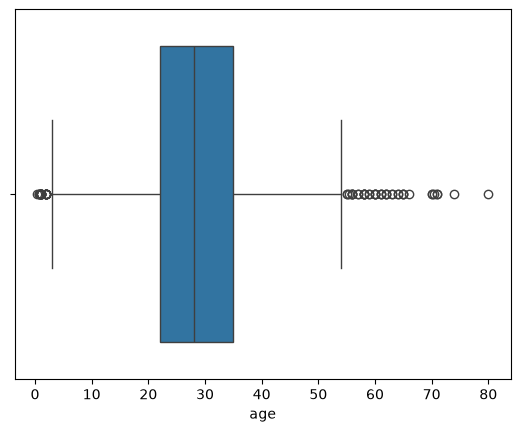

In [28]:
# Boxplot

sns.boxplot(x=df["age"])

In [29]:
# IQR Function

def outliers(col):

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    count=((df[col]<lower)|(df[col]>upper)).sum()

    return count

print(outliers("age"))
print(outliers("fare"))

65
114


In [30]:
# Mean Median Mode

print(df["fare"].mean())
print(df["fare"].median())
print(df["fare"].mode()[0])

32.09668087739032
14.4542
8.05


In [31]:
# Task 4 Bivariate Analysis
# Survival by Sex

male=((df.sex=="male")&(df.survived==1)).sum()/((df.sex=="male").sum())

female=((df.sex=="female")&(df.survived==1)).sum()/((df.sex=="female").sum())

In [32]:
# Survival by Class

for i in [1,2,3]:

    rate=((df.pclass==i)&(df.survived==1)).sum()/(df.pclass==i).sum()

    print(i,rate)

1 0.6261682242990654
2 0.47282608695652173
3 0.24236252545824846


In [33]:
# Sex + Class

pd.crosstab(
    [df.sex,df.pclass],
    df.survived,
    normalize="index"
)

survived              0         1
sex    pclass                    
female 1       0.032609  0.967391
       2       0.078947  0.921053
       3       0.500000  0.500000
male   1       0.631148  0.368852
       2       0.842593  0.157407
       3       0.864553  0.135447

<Axes: >

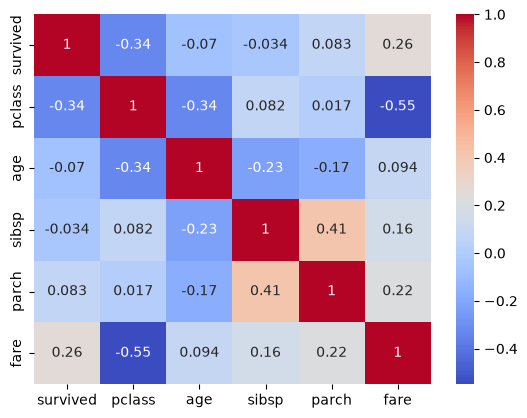

In [34]:
# Correlation Matrix

cols=[
"survived",
"pclass",
"age",
"sibsp",
"parch",
"fare"
]

corr=df[cols].corr()

sns.heatmap(corr,
annot=True,
cmap="coolwarm")


In [35]:
corr_unstack=corr.abs().unstack()

corr_unstack=corr_unstack[corr_unstack<1]

print(corr_unstack.sort_values(ascending=False).drop_duplicates().head(2))

fare   pclass    0.548193
parch  sibsp     0.414542
dtype: float64


In [36]:
# Task 6 Standardization Check

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

temp=df.copy()

temp[["age","fare"]]=scaler.fit_transform(temp[["age","fare"]])

print(temp[["age","fare"]].mean())

print(temp[["age","fare"]].std())

# Means should be near 0

# Standard deviation near 1


age     2.717486e-16
fare    1.398706e-16
dtype: float64
age     1.000563
fare    1.000563
dtype: float64
